# Bank Customer Churn Prediction: Multi-Model Ensemble Approach
> **Project Goal:** Predict customer attrition for a banking institution using an ensemble of Gradient Boosting Decision Trees (GBDT).

## 1. Import Libraries
We import essential libraries for data manipulation, visualization, and advanced machine learning models (XGBoost, CatBoost, LightGBM).

In [1]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Configuration for clean output
set_config(transform_output="pandas")

## 2. Data Loading & Augmentation
To improve the model's generalization capability, we integrate the original bank churn dataset with the competition-specific data.

In [2]:
# Define paths
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data')
MODEL_PATH = os.path.join(BASE_DIR, 'models')
OUTPUT_PATH = os.path.join(BASE_DIR, 'outputs')

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [3]:
# Load datasets
try:
    train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
    test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
    submission_template = pd.read_csv(os.path.join(DATA_PATH, 'submission_template.csv'))
    
    # Original dataset for augmentation
    url = 'https://raw.githubusercontent.com/erkansirin78/datasets/master/Churn_Modelling.csv'
    origin = pd.read_csv(url)
    
    # Merge and clean
    train_drop = train.drop(['id'], axis=1)
    origin_drop = origin.drop(['RowNumber'], axis=1)
    combined = pd.concat([train_drop, origin_drop], axis=0).reset_index(drop=True)
    
    print(f"Data Loaded Successfully. Combined Shape: {combined.shape}")
except FileNotFoundError as e:
    print(f"Error: Ensure CSV files are in the '{DATA_PATH}' directory. {e}")

Data Loaded Successfully. Combined Shape: (25000, 13)


## 3. Exploratory Data Analysis (EDA)
Before preprocessing, we analyze the target distribution and feature correlations to understand the underlying patterns.

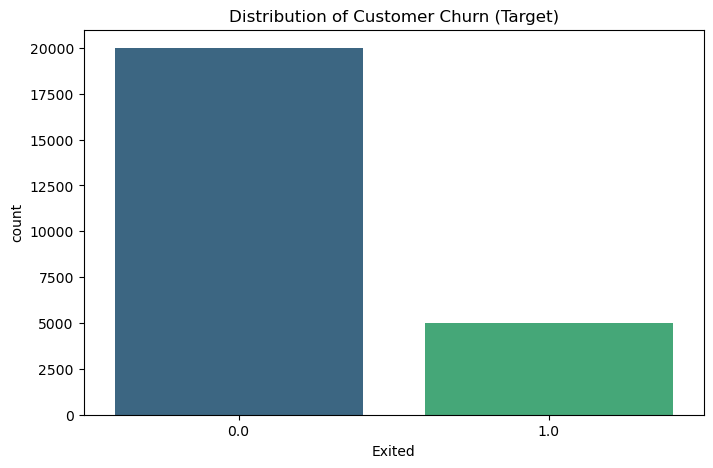

In [4]:
# Target Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=combined, hue='Exited', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn (Target)')
plt.show()

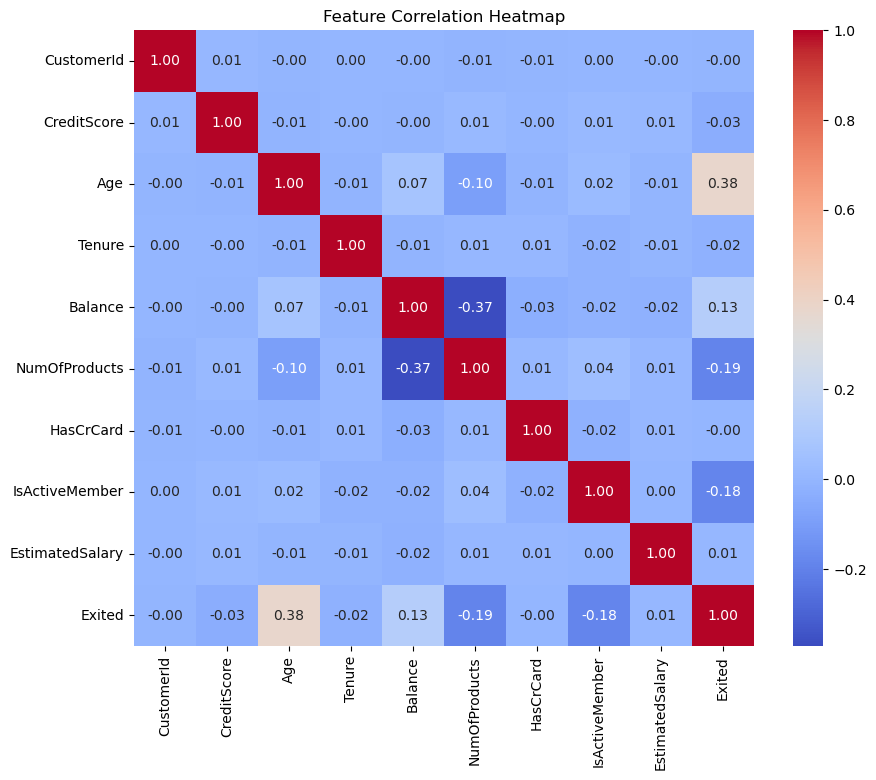

In [5]:
# Correlation Matrix (Numerical Features Only)
numeric_cols = combined.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(combined[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Preprocessing Pipeline
We implement a `ColumnTransformer` to handle categorical encoding and prepare the features for GBDT models.

In [6]:
# Define Features and Target
X = combined.drop(['CustomerId', 'Surname', 'Exited'], axis=1)
y = combined['Exited']

categorical_cols = ['Geography', 'Gender']

# Preprocessing Pipeline
col_trans = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), 
         categorical_cols)
    ],
    remainder='passthrough'
)

# Transform Data
X_processed = col_trans.fit_transform(X)

# Split into Train and Validation sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=22)

## 5. Model Training
We train three different GBDT algorithms. To handle class imbalance, we adjust the `scale_pos_weight` parameter.

In [7]:
# XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
xgb_model = xgb.train({'objective': 'binary:logistic', 'eval_metric': 'logloss', 'max_depth': 3}, 
                      dtrain, num_boost_round=100)

# CatBoost
cat_model = CatBoostClassifier(scale_pos_weight=3, learning_rate=0.03, depth=6, verbose=0)
cat_model.fit(X_train, y_train)

# LightGBM
lgb_model = lgb.LGBMClassifier(learning_rate=0.01, max_depth=10, num_leaves=40, scale_pos_weight=4)
lgb_model.fit(X_train, y_train)

print("All models trained successfully.")

[LightGBM] [Info] Number of positive: 4009, number of negative: 15991
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200450 -> initscore=-1.383484
[LightGBM] [Info] Start training from score -1.383484
All models trained successfully.


## 6. Model Evaluation & Interpretation
We evaluate each model's performance and analyze which features are the primary drivers of customer churn.

In [8]:
# Print Performance Reports
dtest = xgb.DMatrix(X_test)
y_prob_xgb = xgb_model.predict(dtest)
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)
print("\n--- XGBoost Report ---")
print(classification_report(y_test, y_pred_xgb))

for name, model in [("CatBoost", cat_model), ("LightGBM", lgb_model)]:
    y_pred = model.predict(X_test)
    print(f"\n--- {name} Report ---")
    print(classification_report(y_test, y_pred))


--- XGBoost Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93      3995
         1.0       0.79      0.59      0.67      1005

    accuracy                           0.89      5000
   macro avg       0.85      0.77      0.80      5000
weighted avg       0.88      0.89      0.88      5000


--- CatBoost Report ---
              precision    recall  f1-score   support

         0.0       0.94      0.89      0.92      3995
         1.0       0.65      0.76      0.70      1005

    accuracy                           0.87      5000
   macro avg       0.79      0.83      0.81      5000
weighted avg       0.88      0.87      0.87      5000


--- LightGBM Report ---
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93      3995
         1.0       0.71      0.70      0.70      1005

    accuracy                           0.88      5000
   macro avg       0.81      0.81      0.81      5000


<Figure size 1000x600 with 0 Axes>

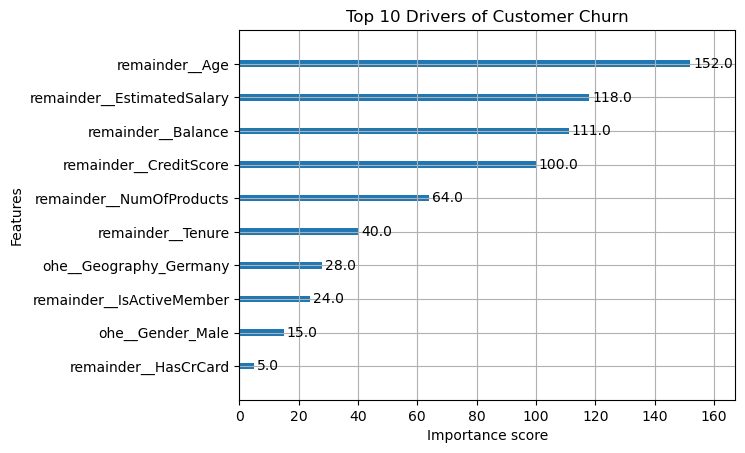

In [9]:
# Feature Importance (XGBoost)
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title('Top 10 Drivers of Customer Churn')
plt.show()

## 7. Final Prediction (Soft Voting Ensemble)
Instead of relying on a single model, we combine the probabilities from all three models to generate a more stable and accurate final prediction.

In [10]:
# Ensemble Performance Validation (For Portfolio)

# Get probabilities from each model for validation
# XGBoost
dtest_val = xgb.DMatrix(X_test)
val_prob_xgb = xgb_model.predict(dtest_val)
# CatBoost
val_prob_cat = cat_model.predict_proba(X_test)[:, 1]
# LightGBM
val_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Soft Voting: Average of probabilities
val_final_prob = (val_prob_xgb + val_prob_cat + val_prob_lgb) / 3
val_final_preds = (val_final_prob > 0.5).astype(int)

# Print Performance Report
print("--- [FINAL] Soft Voting Ensemble Performance Report ---")
print(classification_report(y_test, val_final_preds))
print(f"Final Ensemble ROC-AUC Score: {roc_auc_score(y_test, val_final_prob):.4f}")

--- [FINAL] Soft Voting Ensemble Performance Report ---
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93      3995
         1.0       0.71      0.69      0.70      1005

    accuracy                           0.88      5000
   macro avg       0.82      0.81      0.82      5000
weighted avg       0.88      0.88      0.88      5000

Final Ensemble ROC-AUC Score: 0.9200


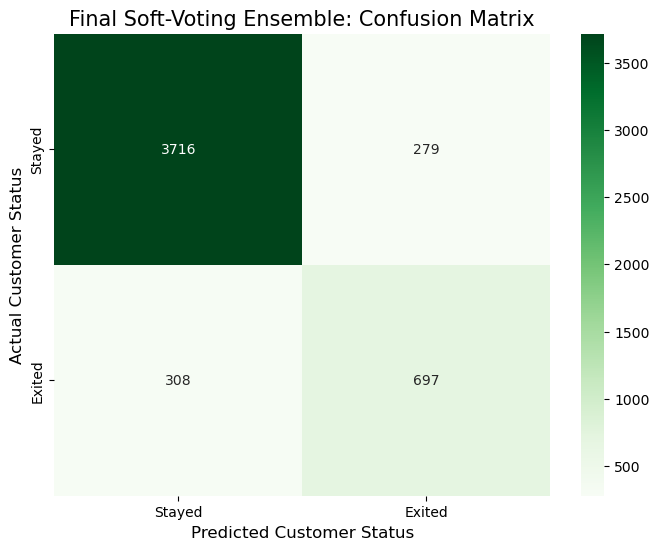

In [11]:
# Generate Confusion Matrix using the final ensemble predictions (val_final_preds)
cm_ensemble = confusion_matrix(y_test, val_final_preds)

# Visualize the Confusion Matrix using a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Exited'], 
            yticklabels=['Stayed', 'Exited'])

plt.title('Final Soft-Voting Ensemble: Confusion Matrix', fontsize=15)
plt.ylabel('Actual Customer Status', fontsize=12)
plt.xlabel('Predicted Customer Status', fontsize=12)
plt.show()

In [12]:
# Final Prediction & Submission File Generation

# Preprocess the test data
test_temp = test.drop(['id', 'CustomerId', 'Surname'], axis=1)
test_processed = col_trans.transform(test_temp)

# Get Probabilities from each model
# XGBoost
dtest_final = xgb.DMatrix(test_processed)
prob_xgb = xgb_model.predict(dtest_final)
# CatBoost
prob_cat = cat_model.predict_proba(test_processed)[:, 1]
# LightGBM
prob_lgb = lgb_model.predict_proba(test_processed)[:, 1]

# Soft Voting: Average of probabilities
final_prob = (prob_xgb + prob_cat + prob_lgb) / 3
final_preds = (final_prob > 0.5).astype(int)

# Create submission file
from datetime import datetime
current_date = datetime.now().strftime('%Y%m%d')
filename = f'Final_Churn_Predictions_{current_date}.csv'

SUBMISSION_PATH = os.path.join(OUTPUT_PATH, filename)
submission_template['Exited'] = final_preds
submission_template.to_csv(SUBMISSION_PATH, index=False)

print(f"✅ Final Ensemble Submission file has been saved to: {SUBMISSION_PATH}")

✅ Final Ensemble Submission file has been saved to: C:\Users\PC\Desktop\GitHub\2. Bank-Churn-Prediction-Ensemble\outputs\Final_Churn_Predictions_20260330.csv


--- Final Prediction Preview (Top 10) ---
      id  Exited
0  15000       0
1  15001       0
2  15002       0
3  15003       0
4  15004       0
5  15005       1
6  15006       1
7  15007       0
8  15008       1
9  15009       0

--- Prediction Distribution ---
Exited
0    0.8066
1    0.1934
Name: proportion, dtype: float64


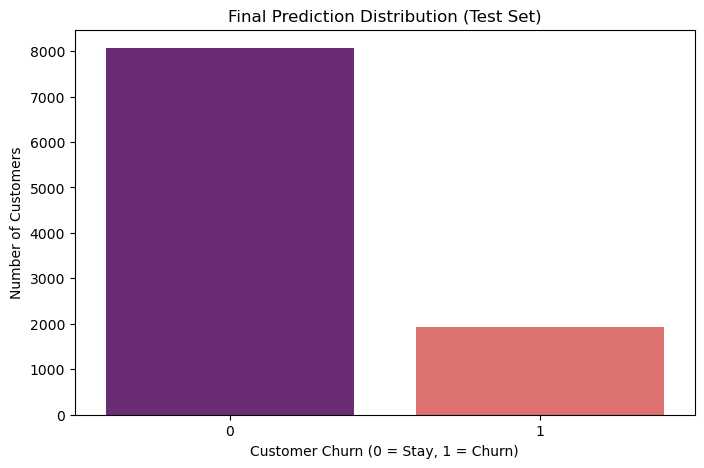

✅ Final Ensemble Submission file has been verified: Final_Churn_Predictions_20260330.csv


In [13]:
# Final Submission File Verification

# Load the generated submission file to verify results
FILE_PATH = os.path.join(OUTPUT_PATH, filename)
submission_results = pd.read_csv(FILE_PATH)

# Display the first 10 rows of the final predictions
print("--- Final Prediction Preview (Top 10) ---")
print(submission_results.head(10))

# Check the distribution of predicted classes (0: Stay, 1: Churn)
print("\n--- Prediction Distribution ---")
print(submission_results['Exited'].value_counts(normalize=True))

# Visualize the final prediction counts
plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=submission_results, hue='Exited', palette='magma', legend=False)
plt.title('Final Prediction Distribution (Test Set)')
plt.xlabel('Customer Churn (0 = Stay, 1 = Churn)')
plt.ylabel('Number of Customers')
plt.show()

print(f"✅ Final Ensemble Submission file has been verified: {filename}")

### 8. Deployment 

This section exports the trained model and its associated assets to be used in **the Streamlit web application**.

In [14]:
# Final Esport for deployment
PREPROCESSOR_PATH = os.path.join(MODEL_PATH, 'preprocessor.pkl')
XGB_PATH = os.path.join(MODEL_PATH, 'model_xgb.pkl')
CAT_PATH = os.path.join(MODEL_PATH, 'model_cat.pkl')
LGB_PATH = os.path.join(MODEL_PATH, 'model_lgb.pkl')

# Save the preprocessing pipeline (ColumnTransformer)
# This ensures consistent feature transformation during inference
joblib.dump(col_trans, PREPROCESSOR_PATH)

# Save individual ensemble members
# Serializing XGBoost, CatBoost, and LightGBM for the soft-voting logic
joblib.dump(xgb_model, XGB_PATH)
joblib.dump(cat_model, CAT_PATH)
joblib.dump(lgb_model, LGB_PATH)

filenames = [os.path.basename(p) for p in [PREPROCESSOR_PATH, XGB_PATH, CAT_PATH, LGB_PATH]]
print("🚀 Deployment assets exported successfully.")
print(f"📂 Location: {MODEL_PATH}")
print(f"📦 Saved Files: {filenames}")

🚀 Deployment assets exported successfully.
📂 Location: C:\Users\PC\Desktop\GitHub\2. Bank-Churn-Prediction-Ensemble\models
📦 Saved Files: ['preprocessor.pkl', 'model_xgb.pkl', 'model_cat.pkl', 'model_lgb.pkl']
